In [1]:
%%capture
!pip install evaluate rouge_score nltk bert_score pandas matplotlib

🚀 Đang khởi động dàn giám khảo ảo thuật...


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


📊 Đang đọc file và chấm điểm lại... (Đợi RoBERTa 1 chút nhé)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Đã xuất CSV thần tốc tại /kaggle/working/a_compare.csv



,Model,Exact Match,BLEU,ROUGE-L,METEOR,BERT_F1,Gemini_Judge
0,B1 (Zero-Shot),0.0000,0.0456,0.3293,0.2904,0.7426,0.38
1,B2 (SFT),0.2423,0.4149,0.6963,0.6450,0.8953,0.74
2,B3 (RL-DPO),0.2346,0.4022,0.6905,0.6369,0.8930,0.75


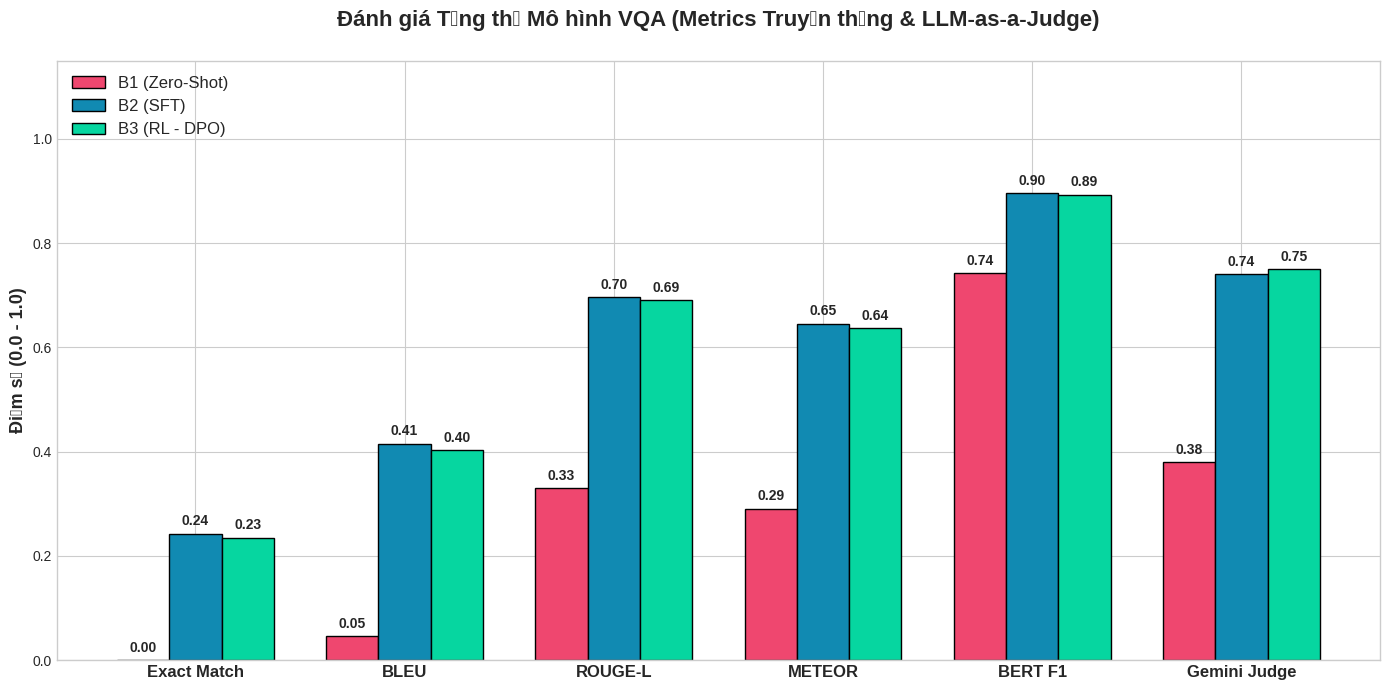

In [2]:
import json
import evaluate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Tắt mấy cái log rác đi cho ngầu

# Đổi tên thư mục này thành tên folder output bạn vừa add vào Input
INPUT_DIR = "/kaggle/input/notebooks/spixalo/dl-endterm-b-allmetrics" 

# Điền 3 con số Gemini Judge bạn đã chấm được ở lần chạy trước
gemini_scores = [0.38, 0.74, 0.75] # <--- THAY SỐ CỦA VERSION TRƯỚC VÀO ĐÂY
# ==============================================================================

print("🚀 Đang khởi động dàn giám khảo ảo thuật...")
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")
bertscore = evaluate.load("bertscore")

def get_metrics_from_ashes(filename):
    with open(f"{INPUT_DIR}/{filename}", "r", encoding="utf-8") as f:
        data = json.load(f)
    preds = [item["prediction"].lower() for item in data]
    refs = [item["ground_truth"].lower() for item in data]
    
    em = sum(1 for p, r in zip(preds, refs) if p == r) / len(preds)
    b = bleu.compute(predictions=preds, references=refs)['bleu']
    rl = rouge.compute(predictions=preds, references=refs)['rougeL']
    m = meteor.compute(predictions=preds, references=refs)['meteor']
    bs = sum(bertscore.compute(predictions=preds, references=refs, lang="vi")['f1']) / len(preds)
    
    return [round(em, 4), round(b, 4), round(rl, 4), round(m, 4), round(bs, 4)]

print("📊 Đang đọc file và chấm điểm lại... (Đợi RoBERTa 1 chút nhé)")
b1_final = get_metrics_from_ashes("preds_b1.json") + [gemini_scores[0]]
b2_final = get_metrics_from_ashes("preds_b2.json") + [gemini_scores[1]]
b3_final = get_metrics_from_ashes("preds_b3.json") + [gemini_scores[2]]

# --- XUẤT CSV ---
df = pd.DataFrame({
    "Model": ["B1 (Zero-Shot)", "B2 (SFT)", "B3 (RL-DPO)"],
    "Exact Match": [b1_final[0], b2_final[0], b3_final[0]],
    "BLEU": [b1_final[1], b2_final[1], b3_final[1]],
    "ROUGE-L": [b1_final[2], b2_final[2], b3_final[2]],
    "METEOR": [b1_final[3], b2_final[3], b3_final[3]],
    "BERT_F1": [b1_final[4], b2_final[4], b3_final[4]],
    "Gemini_Judge": gemini_scores
})
df.to_csv("/kaggle/working/a_compare.csv", index=False)
print("✅ Đã xuất CSV thần tốc tại /kaggle/working/a_compare.csv\n")
display(df)

# --- VẼ BIỂU ĐỒ ---
plt.style.use('seaborn-v0_8-whitegrid')
metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERT F1', 'Gemini Judge']
colors = ['#EF476F', '#118AB2', '#06D6A0']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width, b1_final, width, label='B1 (Zero-Shot)', color=colors[0], edgecolor='black')
rects2 = ax.bar(x, b2_final, width, label='B2 (SFT)', color=colors[1], edgecolor='black')
rects3 = ax.bar(x + width, b3_final, width, label='B3 (RL - DPO)', color=colors[2], edgecolor='black')

ax.set_ylabel('Điểm số (0.0 - 1.0)', fontsize=13, fontweight='bold')
ax.set_title('Đánh giá Tổng thể Mô hình VQA (Metrics Truyền thống & LLM-as-a-Judge)', fontsize=16, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=12, loc='upper left')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()